# Cek GPU

In [2]:
# Cek ketersediaan GPU
import torch
print(f"CUDA tersedia : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU tidak ditemukan. Ganti runtime ke CPU.")
    
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.version.cuda)
print(torch.__version__)
print(torch.version.cuda)
print(torch.backends.cudnn.version())

CUDA tersedia : True
GPU           : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM          : 8.6 GB
True
1
12.6
2.8.0+cu126
12.6
91002


# Instalasi & Import Library

In [3]:
# Install Ultralytics (YOLOv8)
!pip install ultralytics --quiet

# Verifikasi instalasi
import ultralytics
ultralytics.checks()
print(f"Ultralytics {ultralytics.__version__} siap digunakan")

Ultralytics 8.4.87  Python-3.9.25 torch-2.8.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Setup complete  (16 CPUs, 11.7 GB RAM, 257.7/953.9 GB disk)
Ultralytics 8.4.87 siap digunakan


In [4]:
import os
import shutil
import yaml
import cv2
from pathlib import Path
from ultralytics import YOLO
from IPython.display import Image, Video, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("Semua library berhasil di-import")

Semua library berhasil di-import


# Konfigurasi Path Data

In [5]:
LOCAL_DATA_DIR = "data"
YAML_FILENAME   = "data.yaml"
VIDEO_FILENAME  = "sample_video.mp4"

RESULTS_DIR = "pothole_results"

# Yaml Data

In [6]:
local_path = Path(LOCAL_DATA_DIR)
print(f'Dataset is already locally present at {local_path}')
# if local_path.exists():
#     shutil.rmtree(local_path)

yaml_path = local_path / YAML_FILENAME

# Baca YAML
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("Isi data.yaml asli:")
print(yaml.dump(data_config, default_flow_style=False))

# Update path ke lokal
data_config['path']  = LOCAL_DATA_DIR
data_config['train'] = 'train/images'
data_config['val']   = 'valid/images'

# Pastikan field 'nc' dan 'names' ada
if 'nc' not in data_config:
    data_config['nc'] = 1
    print("'nc' tidak ditemukan, diset ke 1 (pothole)")
if 'names' not in data_config:
    data_config['names'] = ['pothole']
    print("'names' tidak ditemukan, diset ke ['pothole']")

# Simpan kembali
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("\ndata.yaml setelah update:")
with open(yaml_path) as f:
    print(f.read())

print(f"Jumlah kelas : {data_config['nc']}")
print(f"Nama kelas  : {data_config['names']}")

Dataset is already locally present at data
Isi data.yaml asli:
names:
- pothole
nc: 1
path: data
train: train/images
val: valid/images


data.yaml setelah update:
names:
- pothole
nc: 1
path: data
train: train/images
val: valid/images

Jumlah kelas : 1
Nama kelas  : ['pothole']


# EDA

Contoh gambar dari data TRAIN:


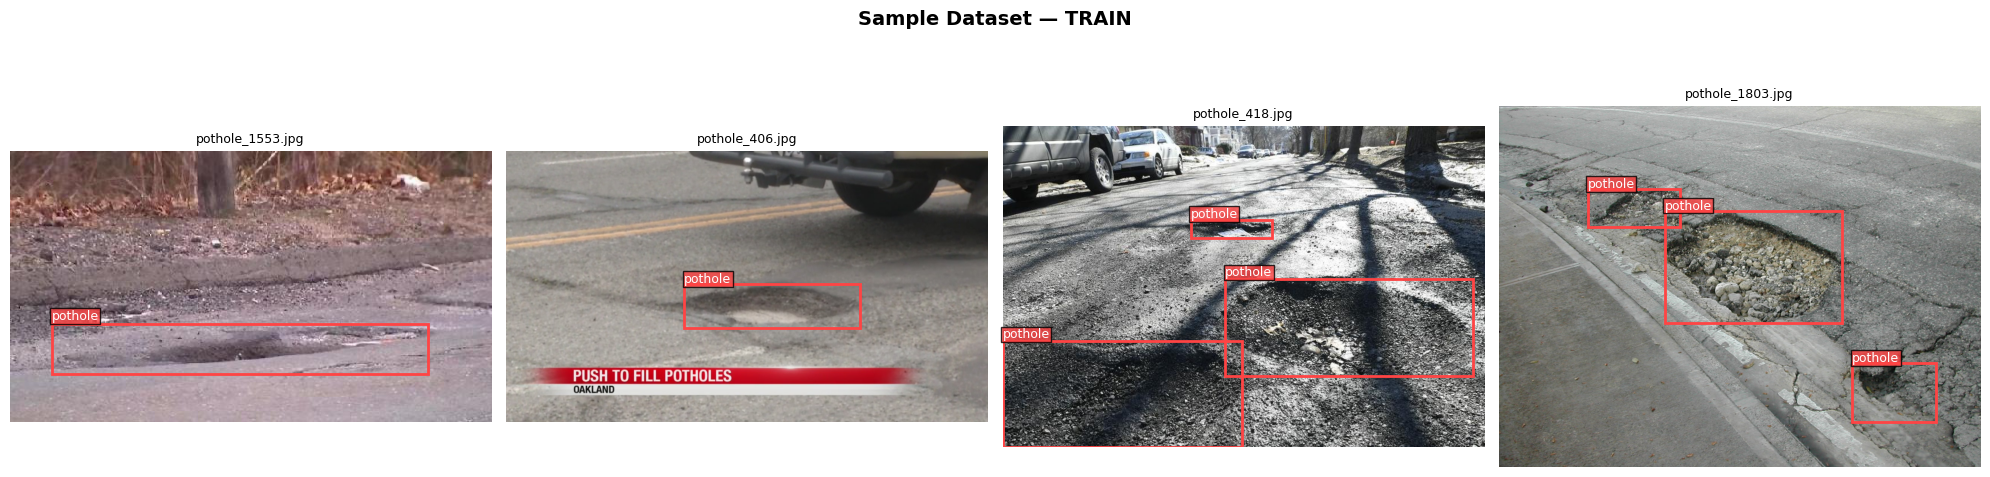


Contoh gambar dari data VALID:


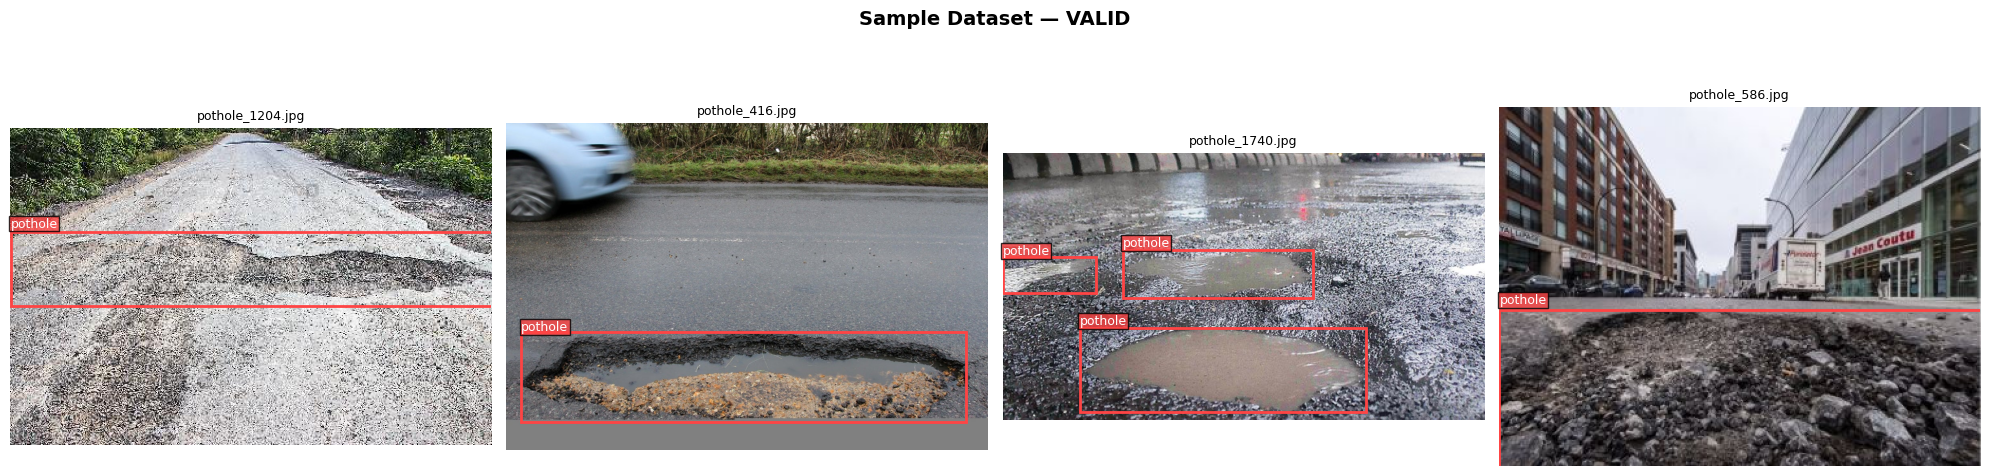

In [7]:
import random
import numpy as np
from PIL import Image as PILImage

def visualize_sample(split='train', n_samples=4):
    img_dir   = local_path / split / 'images'
    label_dir = local_path / split / 'labels'
    img_files = sorted(img_dir.glob('*.jpg'))

    if not img_files:
        print(f"Tidak ada gambar di {img_dir}")
        return

    samples = random.sample(img_files, min(n_samples, len(img_files)))
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, samples):
        img = PILImage.open(img_path)
        w, h = img.size
        ax.imshow(img)

        # Gambar bounding box dari label
        label_path = label_dir / (img_path.stem + '.txt')
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = map(float, parts)
                        x1 = (cx - bw/2) * w
                        y1 = (cy - bh/2) * h
                        rect = plt.Rectangle(
                            (x1, y1), bw * w, bh * h,
                            linewidth=2, edgecolor='#FF4444',
                            facecolor='none'
                        )
                        ax.add_patch(rect)
                        ax.text(x1, y1 - 5, 'pothole',
                                color='white', fontsize=9,
                                bbox=dict(facecolor='#FF4444', alpha=0.8, pad=1))

        ax.set_title(img_path.name, fontsize=9)
        ax.axis('off')

    plt.suptitle(f'Sample Dataset — {split.upper()}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("Contoh gambar dari data TRAIN:")
visualize_sample('train', 4)
print("\nContoh gambar dari data VALID:")
visualize_sample('valid', 4)

In [8]:
# Statistik dataset
print("Statistik Dataset")
print("=" * 40)
for split in ['train', 'valid']:
    img_dir   = local_path / split / 'images'
    label_dir = local_path / split / 'labels'
    n_imgs    = len(list(img_dir.glob('*.jpg')))
    n_labels  = len(list(label_dir.glob('*.txt')))

    # Hitung total objek
    total_obj = 0
    for lf in label_dir.glob('*.txt'):
        with open(lf) as f:
            total_obj += sum(1 for line in f if line.strip())

    avg = total_obj / n_labels if n_labels > 0 else 0
    print(f"  {split.upper():6s} → {n_imgs:4d} gambar | {n_labels:4d} label | {total_obj:5d} objek | rata-rata {avg:.1f} obj/gambar")

print("=" * 40)

Statistik Dataset
  TRAIN  → 1581 gambar | 1581 label |  5942 objek | rata-rata 3.8 obj/gambar
  VALID  →  396 gambar |  396 label |  1395 objek | rata-rata 3.5 obj/gambar


# Preprocessing

In [9]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

def resize_and_pad(img, target_size=(640, 640)):
    h, w = img.shape[:2]
    sh, sw = target_size
    aspect = w / h

    if aspect > sw / sh:
        new_w, new_h = sw, int(sw / aspect)
    else:
        new_h, new_w = sh, int(sh * aspect)

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    canvas = np.zeros((sh, sw, 3), dtype=np.uint8)
    pad_y, pad_x = (sh - new_h) // 2, (sw - new_w) // 2
    canvas[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = resized

    return canvas, (new_w, new_h, pad_x, pad_y)

def normalize_pixels(img):
    return img.astype(np.float32) / 255.0

In [10]:
from pathlib import Path

def process_split(split='train', target_size=(640, 640)):
    src_img_dir = local_path / split / 'images'
    src_label_dir = local_path / split / 'labels'
    dst_img_dir = Path(RESULTS_DIR) / split / 'images'
    dst_label_dir = Path(RESULTS_DIR) / split / 'labels'
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_label_dir.mkdir(parents=True, exist_ok=True)

    sw, sh = target_size
    processed = 0
    for img_path in sorted(src_img_dir.glob('*.jpg')):
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        h, w = img.shape[:2]
        # Apply CLAHE and resize+pad
        img_clahe = apply_clahe(img)
        canvas, (new_w, new_h, pad_x, pad_y) = resize_and_pad(img_clahe, target_size)

        # Read original label (YOLO: cls cx cy w h normalized)
        label_path = src_label_dir / (img_path.stem + '.txt')
        out_label_path = dst_label_dir / (img_path.stem + '.txt')
        out_lines = []
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls = parts[0]
                    cx, cy, bw, bh = map(float, parts[1:])

                    # to absolute coordinates in original image
                    cx_abs = cx * w
                    cy_abs = cy * h
                    bw_abs = bw * w
                    bh_abs = bh * h

                    # scale to resized image and add padding
                    sx = new_w / w
                    sy = new_h / h
                    cx_abs = cx_abs * sx + pad_x
                    cy_abs = cy_abs * sy + pad_y
                    bw_abs = bw_abs * sx
                    bh_abs = bh_abs * sy

                    # normalize to target canvas
                    cx_n = cx_abs / sw
                    cy_n = cy_abs / sh
                    bw_n = bw_abs / sw
                    bh_n = bh_abs / sh

                    out_lines.append(f"{cls} {cx_n:.6f} {cy_n:.6f} {bw_n:.6f} {bh_n:.6f}")

        # Save processed image and updated label
        cv2.imwrite(str(dst_img_dir / img_path.name), canvas)
        with open(out_label_path, 'w') as f:
            if out_lines:
                f.write("\n".join(out_lines))
        processed += 1

    print(f"{split}: diproses {processed} gambar -> {dst_img_dir}")

def process_all(target_size=(640, 640)):
    for split in ['train', 'valid']:
        process_split(split, target_size)

# Jalankan pipeline
process_all(target_size=(640, 640))

train: diproses 1581 gambar -> pothole_results\train\images
valid: diproses 396 gambar -> pothole_results\valid\images


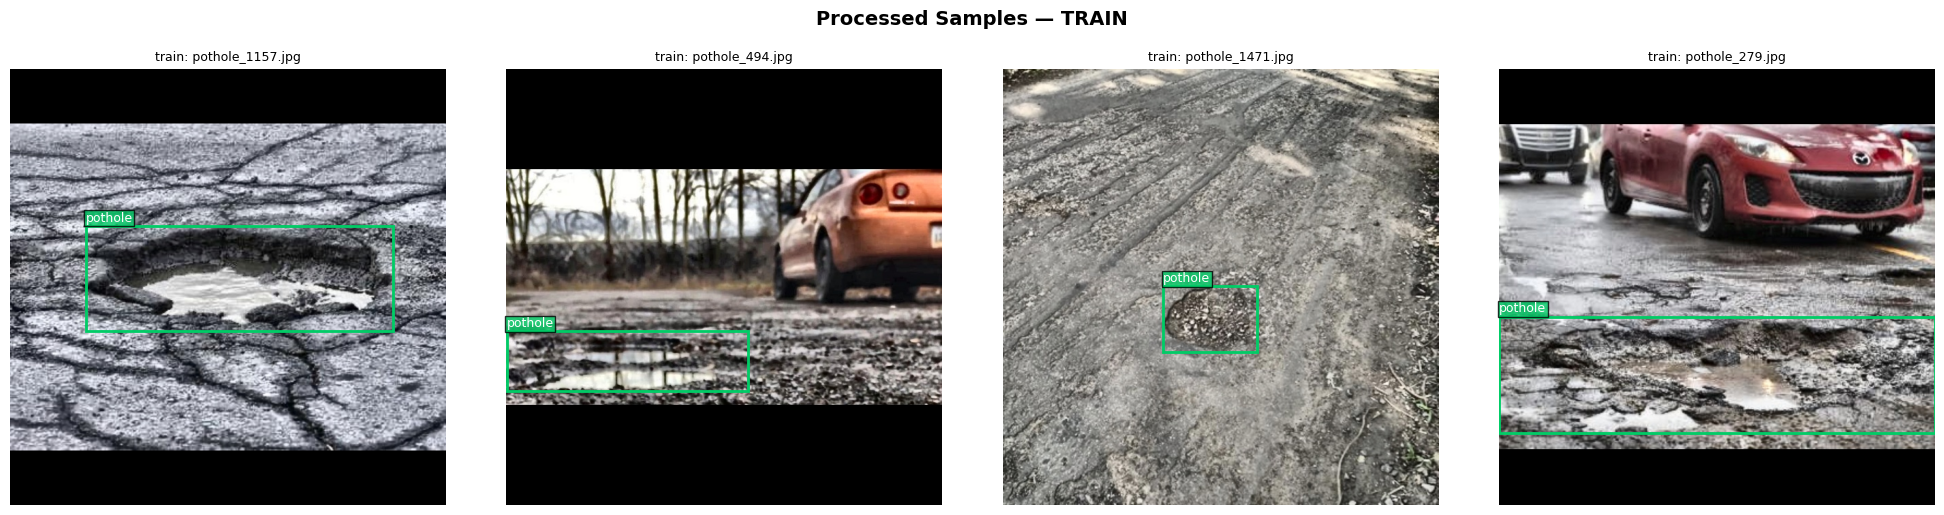

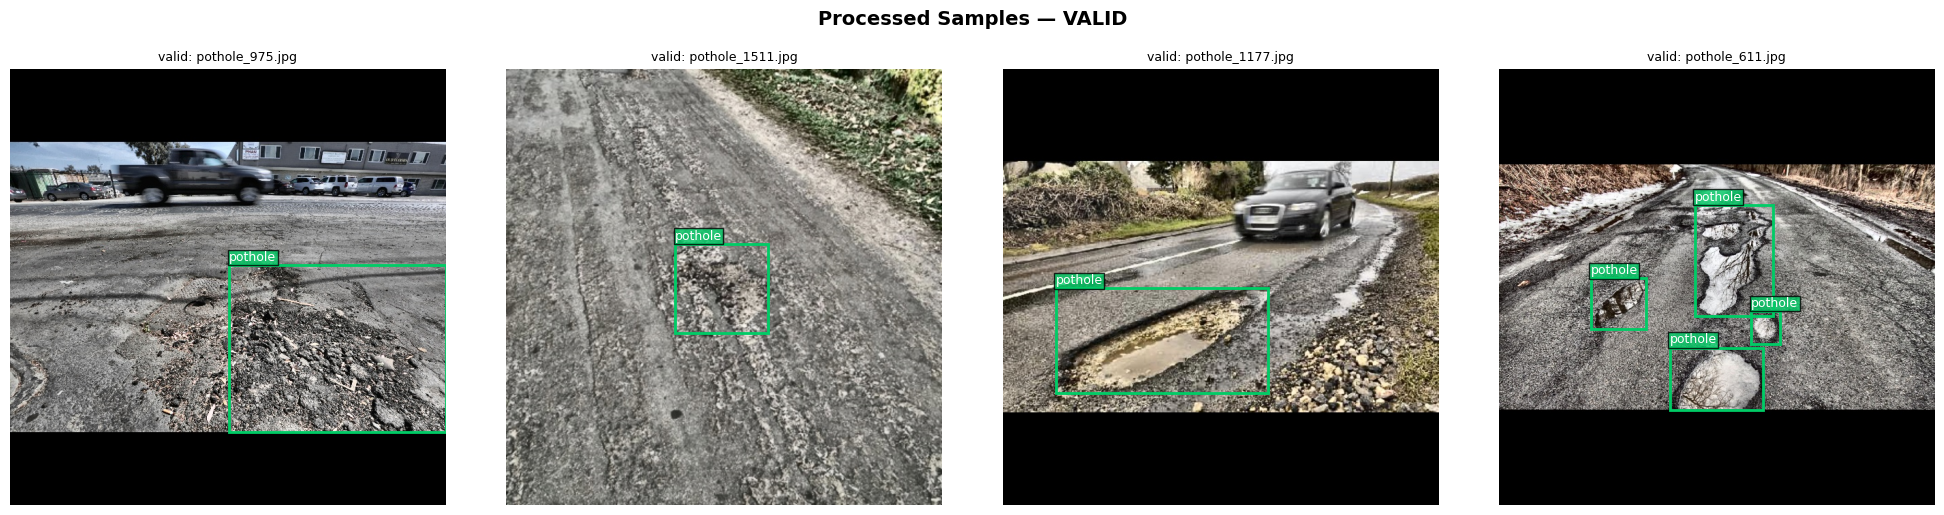

In [11]:
from pathlib import Path
import random
from PIL import Image as PILImage

import matplotlib.pyplot as plt

def visualize_processed(split='train', n_samples=4):
    img_dir = Path(RESULTS_DIR) / split / 'images'
    label_dir = Path(RESULTS_DIR) / split / 'labels'
    img_files = sorted(img_dir.glob('*.jpg'))
    if not img_files:
        print(f"Tidak ada gambar di {img_dir}")
        return

    samples = random.sample(img_files, min(n_samples, len(img_files)))
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, samples):
        img = PILImage.open(img_path).convert("RGB")
        w, h = img.size
        ax.imshow(img)

        label_path = label_dir / (img_path.stem + '.txt')
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    _, cx, cy, bw, bh = map(float, parts)
                    x1 = (cx - bw/2) * w
                    y1 = (cy - bh/2) * h
                    rect = plt.Rectangle((x1, y1), bw * w, bh * h,
                                         linewidth=2, edgecolor='#00CC66',
                                         facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 6, data_config['names'][0] if 'names' in data_config else 'obj',
                            color='white', fontsize=9,
                            bbox=dict(facecolor='#00CC66', alpha=0.8, pad=1))

        ax.set_title(f"{split}: {img_path.name}", fontsize=9)
        ax.axis('off')

    plt.suptitle(f'Processed Samples — {split.upper()}', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Tampilkan contoh hasil preprocessing untuk TRAIN dan VALID
visualize_processed('train', 4)
visualize_processed('valid', 4)

# Konfigurasi Model

In [12]:
MODEL_SIZE   = 'n'    # 'n'=nano, 's'=small, 'm'=medium, 'l'=large, 'x'=xlarge
EPOCHS       = 30     # jumlah epoch training
IMGSZ        = 640    # ukuran input gambar (px)
BATCH_SIZE   = 16     # batch size (-1 = auto)
PATIENCE     = 15     # early stopping patience (epoch)
LR0          = 0.01   # learning rate awal
WORKERS      = 2      # jumlah worker dataloader
PROJECT_NAME = "pothole_detection"
RUN_NAME     = f"yolov8{MODEL_SIZE}_ep{EPOCHS}"

# Pretrained weights
WEIGHTS = f"yolov8{MODEL_SIZE}.pt"

print(f"Konfigurasi Training:")
print(f"Model     : YOLOv8{MODEL_SIZE} ({WEIGHTS})")
print(f"Epochs    : {EPOCHS}")
print(f"Img size  : {IMGSZ}x{IMGSZ}")
print(f"Batch     : {BATCH_SIZE}")
print(f"Patience  : {PATIENCE}")
print(f"Device    : {'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'}")

Konfigurasi Training:
Model     : YOLOv8n (yolov8n.pt)
Epochs    : 30
Img size  : 640x640
Batch     : 16
Patience  : 15
Device    : GPU (CUDA)


In [13]:
# Load pretrained model
model = YOLO(WEIGHTS)
print(f"Model {WEIGHTS} berhasil dimuat")

Model yolov8n.pt berhasil dimuat


# Hyperparameter Tuning

In [15]:
from itertools import product
import pandas as pd
import time

# Jumlah epoch untuk setiap kombinasi saat grid search (lebih kecil dari EPOCHS agar proses cepat)
TUNE_EPOCHS = 10

# Ruang pencarian hyperparameter
param_grid = {
    'lr0'      : [0.001, 0.01, 0.02],
    'batch'    : [8, 16, 32],
    'optimizer': ['SGD', 'AdamW'],
}

param_names        = list(param_grid.keys())
param_combinations = list(product(*param_grid.values()))

print(f"Total kombinasi hyperparameter : {len(param_combinations)}")
print(f"Epoch per kombinasi (tuning)   : {TUNE_EPOCHS}")
for name, values in param_grid.items():
    print(f"  {name:10s}: {values}")

Total kombinasi hyperparameter : 18
Epoch per kombinasi (tuning)   : 10
  lr0       : [0.001, 0.01, 0.02]
  batch     : [8, 16, 32]
  optimizer : ['SGD', 'AdamW']


In [16]:
# Jalankan grid search: latih model singkat untuk setiap kombinasi, lalu evaluasi mAP50-95
tuning_results = []
DEVICE = 0 if torch.cuda.is_available() else 'cpu'

for i, combo in enumerate(param_combinations, start=1):
    params   = dict(zip(param_names, combo))
    run_name = f"tune_{i:02d}_lr{params['lr0']}_b{params['batch']}_{params['optimizer']}"

    print(f"\n[{i}/{len(param_combinations)}] Mencoba kombinasi: {params}")

    try:
        start = time.time()

        # Muat ulang bobot pretrained agar setiap kombinasi mulai dari kondisi awal yang sama
        tune_model = YOLO(WEIGHTS)
        tune_model.train(
            data      = str(yaml_path),
            epochs    = TUNE_EPOCHS,
            imgsz     = IMGSZ,
            batch     = params['batch'],
            lr0       = params['lr0'],
            optimizer = params['optimizer'],
            patience  = TUNE_EPOCHS,   # nonaktifkan early stopping selama tuning singkat
            workers   = WORKERS,
            device    = DEVICE,
            project   = f"{PROJECT_NAME}_tuning",
            name      = run_name,
            exist_ok  = True,
            pretrained= True,
            plots     = False,
            verbose   = False,
        )

        val_metrics = tune_model.val(
            data    = str(yaml_path),
            imgsz   = IMGSZ,
            device  = DEVICE,
            verbose = False,
        ).results_dict

        elapsed = time.time() - start

        tuning_results.append({
            **params,
            'run_name'   : run_name,
            'mAP50'      : val_metrics.get('metrics/mAP50(B)', 0),
            'mAP50-95'   : val_metrics.get('metrics/mAP50-95(B)', 0),
            'precision'  : val_metrics.get('metrics/precision(B)', 0),
            'recall'     : val_metrics.get('metrics/recall(B)', 0),
            'waktu_detik': round(elapsed, 1),
        })

        print(f"   mAP50-95 = {tuning_results[-1]['mAP50-95']:.4f} | waktu = {elapsed:.1f}s")

    except Exception as e:
        print(f"   Gagal pada kombinasi {params}: {e}")
        tuning_results.append({
            **params,
            'run_name'   : run_name,
            'mAP50'      : 0,
            'mAP50-95'   : 0,
            'precision'  : 0,
            'recall'     : 0,
            'waktu_detik': None,
        })

print("\nGrid search selesai!")


[1/18] Mencoba kombinasi: {'lr0': 0.001, 'batch': 8, 'optimizer': 'SGD'}
Ultralytics 8.4.87  Python-3.9.25 torch-2.8.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tune_01_lr0.001_b8_S

In [17]:
# Kumpulkan hasil ke DataFrame dan urutkan berdasarkan mAP50-95 (metrik yang dimaksimalkan)
tuning_df = pd.DataFrame(tuning_results).sort_values('mAP50-95', ascending=False).reset_index(drop=True)

print("Hasil Grid Search (diurutkan berdasarkan mAP50-95):")
display(tuning_df)

best_row    = tuning_df.iloc[0]
best_params = {
    'lr0'      : float(best_row['lr0']),
    'batch'    : int(best_row['batch']),
    'optimizer': best_row['optimizer'],
}

print("\n" + "=" * 45)
print("HYPERPARAMETER TERBAIK")
print("=" * 45)
for k, v in best_params.items():
    print(f"  {k:10s}: {v}")
print(f"  mAP50-95  : {best_row['mAP50-95']:.4f}")
print(f"  mAP50     : {best_row['mAP50']:.4f}")
print("=" * 45)

Hasil Grid Search (diurutkan berdasarkan mAP50-95):


,lr0,batch,optimizer,run_name,mAP50,mAP50-95,precision,recall,waktu_detik
0,0.001,8,AdamW,tune_02_lr0.001_b8_AdamW,0.743361,0.473735,0.719974,0.669297,348.9
1,0.001,16,AdamW,tune_04_lr0.001_b16_AdamW,0.737283,0.472722,0.731962,0.654300,256.6
2,0.010,32,SGD,tune_11_lr0.01_b32_SGD,0.728729,0.461838,0.730283,0.639885,280.2
3,0.010,16,SGD,tune_09_lr0.01_b16_SGD,0.720976,0.458279,0.733446,0.642037,288.0
4,0.001,32,SGD,tune_05_lr0.001_b32_SGD,0.708837,0.452475,0.719106,0.629125,254.7
5,0.001,16,SGD,tune_03_lr0.001_b16_SGD,0.704044,0.446168,0.737169,0.602582,256.1
6,0.010,8,SGD,tune_07_lr0.01_b8_SGD,0.711315,0.445573,0.736519,0.629654,415.7
7,0.001,8,SGD,tune_01_lr0.001_b8_SGD,0.693576,0.437962,0.720396,0.601865,401.5
8,0.020,32,SGD,tune_17_lr0.02_b32_SGD,0.693254,0.436215,0.721861,0.619799,287.6
9,0.020,8,SGD,tune_13_lr0.02_b8_SGD,0.684447,0.429329,0.707299,0.606887,427.3



HYPERPARAMETER TERBAIK
  lr0       : 0.001
  batch     : 8
  optimizer : AdamW
  mAP50-95  : 0.4737
  mAP50     : 0.7434


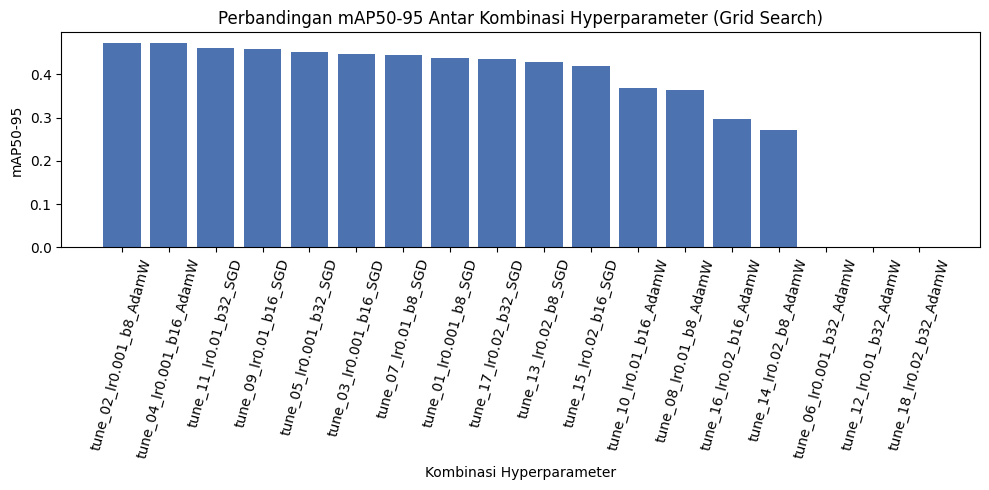

In [18]:
# Visualisasi perbandingan mAP50-95 antar kombinasi hyperparameter
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(tuning_df['run_name'], tuning_df['mAP50-95'], color='#4C72B0')
ax.set_ylabel('mAP50-95')
ax.set_xlabel('Kombinasi Hyperparameter')
ax.set_title('Perbandingan mAP50-95 Antar Kombinasi Hyperparameter (Grid Search)')
ax.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()

# Training dengan Final Parameter

In [14]:
# Terapkan hyperparameter terbaik hasil grid search ke konfigurasi training final
LR0        = 0.001  #best_params['lr0']
BATCH_SIZE = 8  #best_params['batch']
OPTIMIZER  = "AdamW"  #best_params['optimizer']
RUN_NAME   = f"yolov8{MODEL_SIZE}_ep{EPOCHS}_tuned"

# Muat ulang bobot pretrained agar training final dimulai dari kondisi awal yang bersih
model = YOLO(WEIGHTS)

print("Konfigurasi Training Final (setelah tuning):")
print(f"  lr0       : {LR0}")
print(f"  batch     : {BATCH_SIZE}")
print(f"  optimizer : {OPTIMIZER}")
print(f"  run_name  : {RUN_NAME}")

Konfigurasi Training Final (setelah tuning):
  lr0       : 0.001
  batch     : 8
  optimizer : AdamW
  run_name  : yolov8n_ep30_tuned


In [15]:
# MULAI TRAINING
results = model.train(
    data      = str(yaml_path),
    epochs    = EPOCHS,
    imgsz     = IMGSZ,
    batch     = BATCH_SIZE,
    patience  = PATIENCE,
    lr0       = LR0,
    optimizer = OPTIMIZER,
    workers   = WORKERS,
    device    = 0 if torch.cuda.is_available() else 'cpu',
    project   = PROJECT_NAME,
    name      = RUN_NAME,
    exist_ok  = True,
    pretrained= True,
    augment   = True,
    cache     = True,
    plots     = True,
    save      = True,
    verbose   = True,
)

print("\n✅ Training selesai!")

Ultralytics 8.4.87  Python-3.9.25 torch-2.8.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_ep30_tuned, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask

# Evaluasi

In [16]:
# Lokasi hasil training
train_dir = Path(PROJECT_NAME) / RUN_NAME
print(f"Hasil training: {train_dir}")

# Tampilkan grafik training
plot_files = [
    'results.png',
    'confusion_matrix.png',
    'val_batch0_pred.jpg',
    'PR_curve.png',
    'F1_curve.png',
]

for plot_file in plot_files:
    plot_path = train_dir / plot_file
    if plot_path.exists():
        print(f"\n{plot_file}")
        display(Image(filename=str(plot_path), width=800))

Hasil training: pothole_detection\yolov8n_ep30_tuned


In [22]:
# Validasi model terbaik pada data validasi
best_weights = Path("runs") / "detect" / PROJECT_NAME / RUN_NAME / "weights" / "best.pt"
print(f"Memuat bobot terbaik: {best_weights}")

if not best_weights.exists():
    raise FileNotFoundError(f"File tidak ditemukan: {best_weights}")

best_model = YOLO(str(best_weights))
val_results = best_model.val(
    data=str(yaml_path),
    imgsz=IMGSZ,
    device=0 if torch.cuda.is_available() else "cpu",
    verbose=True,
)

print("\n" + "=" * 45)
print("METRIK EVALUASI")
print("=" * 45)
metrics = val_results.results_dict
print(f"   mAP50     : {metrics.get('metrics/mAP50(B)', 0):.4f}")
print(f"   mAP50-95  : {metrics.get('metrics/mAP50-95(B)', 0):.4f}")
print(f"   Precision : {metrics.get('metrics/precision(B)', 0):.4f}")
print(f"   Recall    : {metrics.get('metrics/recall(B)', 0):.4f}")
print("=" * 45)

Memuat bobot terbaik: runs\detect\pothole_detection\yolov8n_ep30_tuned\weights\best.pt
Ultralytics 8.4.87  Python-3.9.25 torch-2.8.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 269.1198.0 MB/s, size: 208.7 KB)
val: Scanning D:\SEMESTER 6\Siklus Hidup Kecerdasan Buatan\project\data\valid\labels.cache... 395 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 396/396  0.0s
val: D:\SEMESTER 6\Siklus Hidup Kecerdasan Buatan\project\data\valid\images\pothole_1870.jpg: ignoring corrupt image/label: Invalid image format GIF. Supported formats are:
images: {'dng', 'jp2', 'jpeg', 'webp', 'jpg', 'avif', 'tif', 'heif', 'tiff', 'png', 'mpo', 'heic', 'bmp'}
videos: {'webm', 'mp4', 'mkv', 'wmv', 'm4v', 'mpg', 'mov', 'gif', 'avi', 'ts', 'mpeg', 'asf'}
val: D:\SEMESTER 6\Siklus Hidup Kecerdasan Buatan\project\data\valid\images\pothole_975.jpg: corrupt JPEG rest

# Inferensi

0: 640x640 3 potholes, 7.2ms
1: 640x640 1 pothole, 7.2ms
2: 640x640 3 potholes, 7.2ms
3: 640x640 1 pothole, 7.2ms
4: 640x640 3 potholes, 7.2ms
5: 640x640 1 pothole, 7.2ms
Speed: 3.0ms preprocess, 7.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\SEMESTER 6\Siklus Hidup Kecerdasan Buatan\project\runs\detect\pothole_detection\yolov8n_ep30_tuned_image_pred


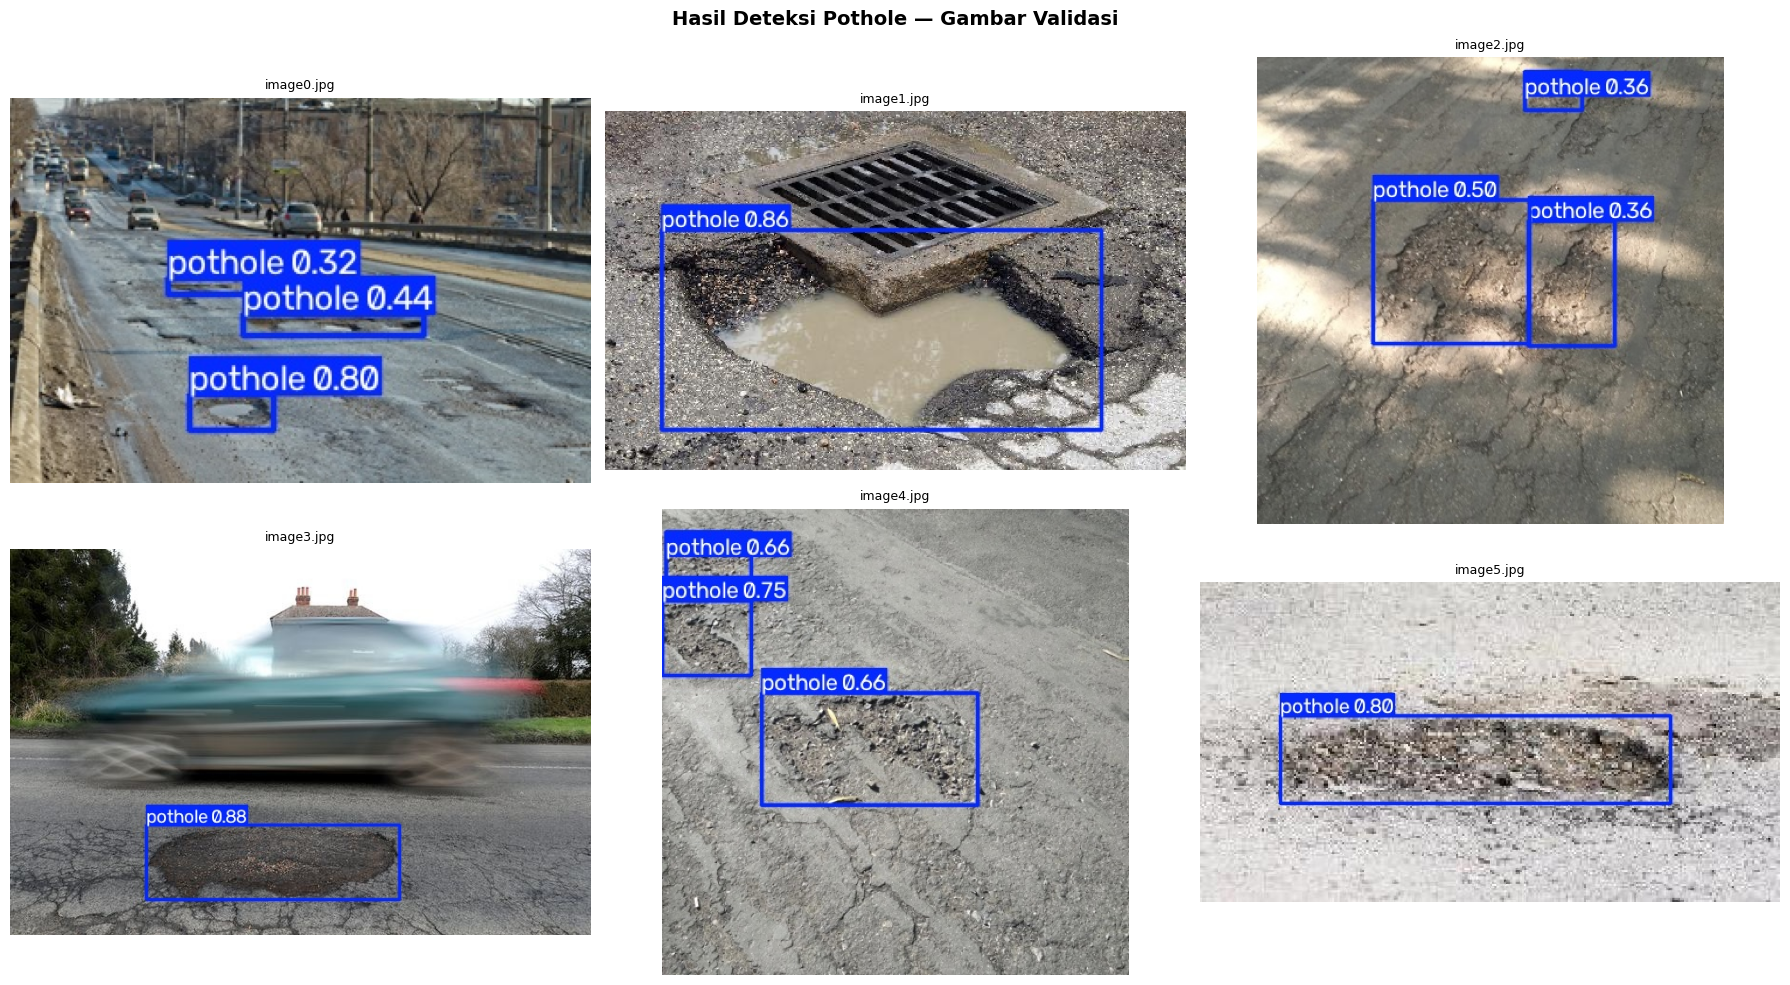

Hasil prediksi gambar disimpan di: runs\detect\pothole_detection\yolov8n_ep30_tuned_image_pred


In [23]:
# Inferensi pada beberapa gambar validasi
val_img_dir = local_path / "valid" / "images"
val_images = sorted(val_img_dir.glob("*.jpg"))[:6]

if val_images:
    preds = best_model.predict(
        source=[str(p) for p in val_images],
        imgsz=IMGSZ,
        conf=0.25,
        iou=0.45,
        device=0 if torch.cuda.is_available() else "cpu",
        save=True,
        project=PROJECT_NAME,
        name=f"{RUN_NAME}_image_pred",
        exist_ok=True,
    )

    pred_dir = Path("runs") / "detect" / PROJECT_NAME / f"{RUN_NAME}_image_pred"
    pred_imgs = sorted(pred_dir.glob("*.jpg"))[:6]

    if not pred_imgs:
        print(f"Tidak ada gambar hasil prediksi di: {pred_dir}")
    else:
        n_cols = 3
        n_rows = (len(pred_imgs) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
        axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

        for ax, pred_img in zip(axes, pred_imgs):
            img = mpimg.imread(str(pred_img))
            ax.imshow(img)
            ax.set_title(pred_img.name, fontsize=9)
            ax.axis("off")

        for ax in axes[len(pred_imgs):]:
            ax.axis("off")

        plt.suptitle("Hasil Deteksi Pothole — Gambar Validasi", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()
        print(f"Hasil prediksi gambar disimpan di: {pred_dir}")
else:
    print("Tidak ada gambar validasi ditemukan")